# Multi-view clustering tối ưu bằng Silhouette

Notebook này train **nhiều clustering model theo từng góc nhìn** thay vì chọn một model duy nhất cho toàn bộ hành vi.

Mỗi view dùng số cụm `k` cố định theo ý nghĩa dữ liệu/persona, sau đó chỉ tune cách biểu diễn bằng silhouette:

- `KMeans` trên feature đã scale.
- `PCA2 + KMeans`.
- `PCA3 + KMeans`.

Notebook **không tune k** nữa để tránh sinh quá nhiều cụm khó giải thích. `t-SNE` không dùng vì không phù hợp để deploy/predict user mới.


In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')
SEED = 42

ROOT = Path('..').resolve()
RAW_PATH = ROOT / 'data/raw/dataset_merged.csv'
CLUSTER_DIR = ROOT / 'results/clustering'
FIGURE_DIR = ROOT / 'figures/clustering'
MODEL_DIR = ROOT / 'models/clustering'

CLUSTER_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)


## 1. Load raw data và split


In [2]:
base_features = [
    'daily_social_media_hours',
    'sleep_hours',
    'screen_time_before_sleep',
    'physical_activity',
    'social_interaction_level',
    'academic_performance',
]

profile_features = [
    'age',
    'gender',
    'platform_usage',
    'stress_level',
    'anxiety_level',
    'depression_label',
]

social_map = {'low': 0, 'medium': 1, 'high': 2}


def encode_social_interaction(series):
    if pd.api.types.is_numeric_dtype(series):
        return series.astype('float32')
    normalized = series.astype(str).str.strip().str.lower()
    encoded = normalized.map(social_map)
    if encoded.isna().any():
        unknown = sorted(normalized[encoded.isna()].unique())
        raise ValueError(f'Unknown social_interaction_level values: {unknown}')
    return encoded.astype('float32')


raw_df = pd.read_csv(RAW_PATH)
required_cols = sorted(set(base_features + profile_features))
missing = [col for col in required_cols if col not in raw_df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

data = raw_df[required_cols].dropna().copy()
data['row_id'] = data.index
data['social_interaction_score'] = encode_social_interaction(data['social_interaction_level'])

stratify_col = data['depression_label'] if 'depression_label' in data.columns else None
train_df, temp_df = train_test_split(
    data,
    test_size=0.30,
    random_state=SEED,
    stratify=stratify_col,
)
temp_stratify = temp_df['depression_label'] if 'depression_label' in temp_df.columns else None
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_stratify,
)

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()
train_df['split'] = 'train'
val_df['split'] = 'validation'
test_df['split'] = 'test'
all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print(f'Train: {train_df.shape}, Validation: {val_df.shape}, Test: {test_df.shape}')
data[base_features + ['social_interaction_score']].head()


Train: (2590, 15), Validation: (555, 15), Test: (555, 15)


,daily_social_media_hours,sleep_hours,screen_time_before_sleep,physical_activity,social_interaction_level,academic_performance,social_interaction_score
0,7.9,7.4,2.9,1.5,low,3.01,0.0
1,1.9,8.0,2.9,0.8,high,3.22,2.0
2,1.3,7.6,0.5,0.0,high,3.92,2.0
3,7.4,6.9,1.6,0.8,medium,3.48,1.0
4,4.7,4.9,3.0,1.4,medium,2.37,1.0


## 2. Định nghĩa từng góc nhìn


In [3]:
multi_view_specs = {
    'usage_intensity': {
        'display_name': 'Usage Intensity',
        'features': ['daily_social_media_hours', 'screen_time_before_sleep', 'sleep_hours'],
        'score_direction': 'high_risk',
        'k': 3,
        'k_reason': 'Usage intensity has three interpretable levels: light/rested, moderate, and heavy/risky use.',
        'name_bank': {
            'low': 'Light / Rested Users',
            'mid': 'Moderate Social Media Users',
            'high': 'Heavy / Night Social Media Users',
        },
    },
    'lifestyle_health': {
        'display_name': 'Lifestyle Health',
        'features': ['sleep_hours', 'physical_activity', 'academic_performance', 'daily_social_media_hours', 'screen_time_before_sleep'],
        'score_direction': 'healthy',
        'k': 2,
        'k_reason': 'Lifestyle separates most clearly into healthy vs risk profiles in this dataset.',
        'name_bank': {
            'low': 'Lifestyle Risk Users',
            'mid': 'Mixed Lifestyle Users',
            'high': 'Healthy Lifestyle Users',
        },
    },
    'social_behavior': {
        'display_name': 'Social Behavior',
        'features': ['social_interaction_score', 'daily_social_media_hours', 'physical_activity'],
        'score_direction': 'social',
        'k': 3,
        'k_reason': 'Social behavior naturally maps to isolated, moderate, and active groups.',
        'name_bank': {
            'low': 'Socially Isolated Users',
            'mid': 'Moderately Social Users',
            'high': 'Socially Active Users',
        },
    },
    'stress_pattern': {
        'display_name': 'Stress Pattern',
        'features': ['stress_level', 'anxiety_level', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep'],
        'score_direction': 'stress',
        'k': 2,
        'k_reason': 'Stress/anxiety split is strongest and clearest as low vs high stress.',
        'name_bank': {
            'low': 'Low Stress Users',
            'mid': 'Moderate Stress Users',
            'high': 'High Stress Users',
        },
    },
}

candidate_methods = ['KMeans', 'PCA2+KMeans', 'PCA3+KMeans']

pd.DataFrame([
    {
        'view': view,
        'display_name': spec['display_name'],
        'features': ', '.join(spec['features']),
        'fixed_k': spec['k'],
        'k_reason': spec['k_reason'],
        'candidate_methods': ', '.join(candidate_methods),
    }
    for view, spec in multi_view_specs.items()
])


,view,display_name,features,fixed_k,k_reason,candidate_methods
0,usage_intensity,Usage Intensity,"daily_social_media_hours, screen_time_before_s...",3,Usage intensity has three interpretable levels...,"KMeans, PCA2+KMeans, PCA3+KMeans"
1,lifestyle_health,Lifestyle Health,"sleep_hours, physical_activity, academic_perfo...",2,Lifestyle separates most clearly into healthy ...,"KMeans, PCA2+KMeans, PCA3+KMeans"
2,social_behavior,Social Behavior,"social_interaction_score, daily_social_media_h...",3,"Social behavior naturally maps to isolated, mo...","KMeans, PCA2+KMeans, PCA3+KMeans"
3,stress_pattern,Stress Pattern,"stress_level, anxiety_level, daily_social_medi...",2,Stress/anxiety split is strongest and clearest...,"KMeans, PCA2+KMeans, PCA3+KMeans"


## 3. Helper functions


In [4]:
def safe_silhouette(X_eval, labels):
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2 or len(unique_labels) >= len(labels):
        return np.nan
    return silhouette_score(X_eval, labels)


def view_score(df, features, direction):
    z = pd.DataFrame(StandardScaler().fit_transform(df[features]), columns=features, index=df.index)
    if direction == 'healthy':
        return (
            z.get('sleep_hours', 0)
            + z.get('physical_activity', 0)
            + z.get('academic_performance', 0)
            - z.get('daily_social_media_hours', 0)
            - z.get('screen_time_before_sleep', 0)
        )
    if direction == 'social':
        return z.get('social_interaction_score', 0) + 0.25 * z.get('physical_activity', 0)
    if direction == 'stress':
        return (
            z.get('stress_level', 0)
            + z.get('anxiety_level', 0)
            + 0.4 * z.get('daily_social_media_hours', 0)
            + 0.3 * z.get('screen_time_before_sleep', 0)
            - 0.4 * z.get('sleep_hours', 0)
        )
    return (
        z.get('daily_social_media_hours', 0)
        + z.get('screen_time_before_sleep', 0)
        - z.get('sleep_hours', 0)
    )


def make_unique_names(raw_names, profiles):
    seen = {}
    final_names = {}
    for _, row in profiles.iterrows():
        cluster_id = row['cluster_id']
        name = raw_names[cluster_id]
        if name in seen:
            detail = (
                f"SM {row['sm_hours_mean']:.1f}h, "
                f"sleep {row['sleep_hours_mean']:.1f}h, "
                f"screen {row['screen_before_sleep_mean']:.1f}h"
            )
            name = f'{name} ({detail})'
        seen[name] = seen.get(name, 0) + 1
        final_names[cluster_id] = name
    return final_names


def name_clusters_from_profiles(view_name, profiles):
    raw_names = {}

    for _, row in profiles.iterrows():
        cluster_id = row['cluster_id']
        sm = row['sm_hours_mean']
        sleep = row['sleep_hours_mean']
        screen = row['screen_before_sleep_mean']
        activity = row['physical_activity_mean']
        academic = row['academic_performance_mean']
        social = row['social_interaction_score_mean']
        stress = row['stress_mean']
        anxiety = row['anxiety_mean']

        if view_name == 'usage_intensity':
            if sm <= 3.4 and sleep >= 6.8:
                name = 'Light / Rested Users'
            elif sm >= 5.0 and screen >= 2.0:
                name = 'Heavy Night Social Media Users'
            elif sm >= 5.0:
                name = 'Heavy Daytime Social Media Users'
            elif screen >= 2.0:
                name = 'Night Screen Users'
            else:
                name = 'Moderate Social Media Users'
        elif view_name == 'lifestyle_health':
            if sleep >= 6.8 and academic >= 3.1 and sm <= 4.0:
                name = 'Healthy Lifestyle Users'
            elif sleep <= 5.8 and academic <= 2.8 and sm >= 5.0:
                name = 'Lifestyle Risk Users'
            elif screen >= 2.0:
                name = 'Late Screen Balanced Users'
            else:
                name = 'Mixed Lifestyle Users'
        elif view_name == 'social_behavior':
            if social <= 0.35 and sm >= 5.5:
                name = 'Isolated Heavy Users'
            elif social <= 0.35:
                name = 'Socially Isolated Users'
            elif social >= 1.65 and stress >= 6.5:
                name = 'Socially Active High Stress Users'
            elif social >= 1.65:
                name = 'Socially Active Users'
            elif activity <= 0.75 and sm >= 5.5:
                name = 'Low Activity Moderate Social Users'
            else:
                name = 'Moderately Social Users'
        elif view_name == 'stress_pattern':
            if stress >= 6.0 or anxiety >= 6.0:
                name = 'High Stress Users'
            else:
                name = 'Low Stress Users'
        else:
            name = f'Cluster {cluster_id}'

        raw_names[cluster_id] = name

    return make_unique_names(raw_names, profiles)


def build_cluster_profiles(profile_df, labels):
    dfp = profile_df.copy()
    dfp['cluster_id'] = labels
    dfp['high_stress_flag'] = (dfp['stress_level'] >= 7).astype(int)
    return dfp.groupby('cluster_id').agg(
        n=('row_id', 'count'),
        sm_hours_mean=('daily_social_media_hours', 'mean'),
        sleep_hours_mean=('sleep_hours', 'mean'),
        screen_before_sleep_mean=('screen_time_before_sleep', 'mean'),
        physical_activity_mean=('physical_activity', 'mean'),
        academic_performance_mean=('academic_performance', 'mean'),
        social_interaction_score_mean=('social_interaction_score', 'mean'),
        stress_mean=('stress_level', 'mean'),
        high_stress_pct=('high_stress_flag', 'mean'),
        anxiety_mean=('anxiety_level', 'mean'),
        depression_pct=('depression_label', 'mean'),
    ).reset_index()


def make_embedding(method, X_train, X_val, X_test, X_all):
    if method == 'KMeans':
        return None, X_train, X_val, X_test, X_all
    n_components = 2 if method == 'PCA2+KMeans' else 3
    reducer = PCA(n_components=n_components, random_state=SEED)
    return (
        reducer,
        reducer.fit_transform(X_train),
        reducer.transform(X_val),
        reducer.transform(X_test),
        reducer.transform(X_all),
    )


## 4. Tối ưu silhouette riêng cho từng view


In [5]:
candidate_rows = []
best_by_view = {}

for view_name, spec in multi_view_specs.items():
    features = spec['features']
    scaler = StandardScaler()
    X_train_base = scaler.fit_transform(train_df[features])
    X_val_base = scaler.transform(val_df[features])
    X_test_base = scaler.transform(test_df[features])
    X_all_base = scaler.transform(all_df[features])

    view_candidates = []
    fixed_k = spec['k']
    for method in candidate_methods:
        reducer, X_train_emb, X_val_emb, X_test_emb, X_all_emb = make_embedding(
            method,
            X_train_base,
            X_val_base,
            X_test_base,
            X_all_base,
        )
        kmeans = KMeans(n_clusters=fixed_k, random_state=SEED, n_init=30)
        train_labels = kmeans.fit_predict(X_train_emb)
        val_labels = kmeans.predict(X_val_emb)
        test_labels = kmeans.predict(X_test_emb)

        row = {
            'view': view_name,
            'display_name': spec['display_name'],
            'method': method,
            'k': fixed_k,
            'k_reason': spec['k_reason'],
            'train_silhouette': safe_silhouette(X_train_emb, train_labels),
            'val_silhouette': safe_silhouette(X_val_emb, val_labels),
            'test_silhouette': safe_silhouette(X_test_emb, test_labels),
        }
        candidate_rows.append(row)
        view_candidates.append({
            **row,
            'scaler': scaler,
            'reducer': reducer,
            'kmeans': kmeans,
            'embeddings': {
                'train': X_train_emb,
                'validation': X_val_emb,
                'test': X_test_emb,
                'all': X_all_emb,
            },
        })

    best = sorted(view_candidates, key=lambda item: item['val_silhouette'], reverse=True)[0]
    best['selection_reason'] = 'fixed k from data interpretation; method selected by validation silhouette'
    best_by_view[view_name] = best

clustering_model_metrics = pd.DataFrame(candidate_rows).sort_values(
    ['view', 'val_silhouette'],
    ascending=[True, False],
)
clustering_model_metrics.to_csv(CLUSTER_DIR / 'multi_view_candidate_silhouette.csv', index=False)

best_view_models = pd.DataFrame([
    {
        'view': view,
        'display_name': multi_view_specs[view]['display_name'],
        'method': best['method'],
        'k': best['k'],
        'train_silhouette': best['train_silhouette'],
        'val_silhouette': best['val_silhouette'],
        'test_silhouette': best['test_silhouette'],
        'k_reason': multi_view_specs[view]['k_reason'],
        'selection_reason': best['selection_reason'],
    }
    for view, best in best_by_view.items()
])
best_view_models.to_csv(CLUSTER_DIR / 'multi_view_clustering_metrics.csv', index=False)

display(best_view_models)
display(clustering_model_metrics.groupby('view').head(5))


,view,display_name,method,k,train_silhouette,val_silhouette,test_silhouette,k_reason,selection_reason
0,usage_intensity,Usage Intensity,PCA2+KMeans,3,0.363755,0.372907,0.374827,Usage intensity has three interpretable levels...,fixed k from data interpretation; method selec...
1,lifestyle_health,Lifestyle Health,PCA2+KMeans,2,0.387932,0.392538,0.380738,Lifestyle separates most clearly into healthy ...,fixed k from data interpretation; method selec...
2,social_behavior,Social Behavior,PCA2+KMeans,3,0.399562,0.386124,0.397887,"Social behavior naturally maps to isolated, mo...",fixed k from data interpretation; method selec...
3,stress_pattern,Stress Pattern,PCA2+KMeans,2,0.407002,0.404053,0.407870,Stress/anxiety split is strongest and clearest...,fixed k from data interpretation; method selec...


,view,display_name,method,k,k_reason,train_silhouette,val_silhouette,test_silhouette
4,lifestyle_health,Lifestyle Health,PCA2+KMeans,2,Lifestyle separates most clearly into healthy ...,0.387932,0.392538,0.380738
5,lifestyle_health,Lifestyle Health,PCA3+KMeans,2,Lifestyle separates most clearly into healthy ...,0.296592,0.301230,0.289437
3,lifestyle_health,Lifestyle Health,KMeans,2,Lifestyle separates most clearly into healthy ...,0.249286,0.251297,0.242265
7,social_behavior,Social Behavior,PCA2+KMeans,3,"Social behavior naturally maps to isolated, mo...",0.399562,0.386124,0.397887
6,social_behavior,Social Behavior,KMeans,3,"Social behavior naturally maps to isolated, mo...",0.266915,0.250801,0.268568
8,social_behavior,Social Behavior,PCA3+KMeans,3,"Social behavior naturally maps to isolated, mo...",0.266915,0.250801,0.268568
10,stress_pattern,Stress Pattern,PCA2+KMeans,2,Stress/anxiety split is strongest and clearest...,0.407002,0.404053,0.407870
11,stress_pattern,Stress Pattern,PCA3+KMeans,2,Stress/anxiety split is strongest and clearest...,0.357316,0.357171,0.354468
9,stress_pattern,Stress Pattern,KMeans,2,Stress/anxiety split is strongest and clearest...,0.315462,0.310844,0.311535
1,usage_intensity,Usage Intensity,PCA2+KMeans,3,Usage intensity has three interpretable levels...,0.363755,0.372907,0.374827


## 5. Export best model từng view và tạo assignments


In [6]:
profile_frames = []
assignment_frames = []
export_rows = []
artifacts = {}

for view_name, best in best_by_view.items():
    spec = multi_view_specs[view_name]
    X_all_emb = best['embeddings']['all']
    all_labels = best['kmeans'].predict(X_all_emb)

    profiles = build_cluster_profiles(all_df, all_labels)
    cluster_name_map = name_clusters_from_profiles(view_name, profiles)
    profiles['view'] = view_name
    profiles['display_name'] = spec['display_name']
    profiles['method'] = best['method']
    profiles['k'] = best['k']
    profiles['cluster_name'] = profiles['cluster_id'].map(cluster_name_map)
    profiles = profiles[
        ['view', 'display_name', 'method', 'k', 'cluster_id', 'cluster_name']
        + [col for col in profiles.columns if col not in ['view', 'display_name', 'method', 'k', 'cluster_id', 'cluster_name']]
    ]
    profile_frames.append(profiles)

    assignments = all_df[['row_id', 'split'] + base_features].copy()
    assignments[f'{view_name}_cluster_id'] = all_labels
    assignments[f'{view_name}_cluster_name'] = assignments[f'{view_name}_cluster_id'].map(cluster_name_map)
    assignment_frames.append(assignments[['row_id', 'split', f'{view_name}_cluster_id', f'{view_name}_cluster_name']])

    artifact = {
        'view': view_name,
        'display_name': spec['display_name'],
        'features': spec['features'],
        'method': best['method'],
        'k': int(best['k']),
        'cluster_name_map': cluster_name_map,
        'social_map': social_map,
        'scaler': best['scaler'],
        'reducer': best['reducer'],
        'kmeans': best['kmeans'],
    }
    artifacts[view_name] = artifact

    safe_method = best['method'].lower().replace('+', 'plus')
    artifact_path = MODEL_DIR / f'{view_name}_{safe_method}_k{best["k"]}.pkl'
    joblib.dump(artifact, artifact_path)

    export_rows.append({
        'view': view_name,
        'display_name': spec['display_name'],
        'method': best['method'],
        'k': best['k'],
        'train_silhouette': best['train_silhouette'],
        'val_silhouette': best['val_silhouette'],
        'test_silhouette': best['test_silhouette'],
        'k_reason': spec['k_reason'],
        'selection_reason': best['selection_reason'],
        'artifact_path': str(artifact_path.relative_to(ROOT)).replace('\\', '/'),
    })

multi_view_profiles = pd.concat(profile_frames, ignore_index=True)
multi_view_assignments = all_df[['row_id', 'split'] + base_features].copy()
for assignment in assignment_frames:
    multi_view_assignments = multi_view_assignments.merge(assignment, on=['row_id', 'split'], how='left')

view_name_cols = [f'{view}_cluster_name' for view in multi_view_specs]
multi_view_assignments['combined_persona'] = multi_view_assignments[view_name_cols].agg(' | '.join, axis=1)
multi_view_models = pd.DataFrame(export_rows)

multi_view_profiles.to_csv(CLUSTER_DIR / 'multi_view_cluster_profiles.csv', index=False)
multi_view_assignments.to_csv(CLUSTER_DIR / 'multi_view_cluster_assignments.csv', index=False)
multi_view_models.to_csv(MODEL_DIR / 'multi_view_clustering_models.csv', index=False)

display(multi_view_models)
display(multi_view_profiles)


,view,display_name,method,k,train_silhouette,val_silhouette,test_silhouette,k_reason,selection_reason,artifact_path
0,usage_intensity,Usage Intensity,PCA2+KMeans,3,0.363755,0.372907,0.374827,Usage intensity has three interpretable levels...,fixed k from data interpretation; method selec...,models/clustering/usage_intensity_pca2pluskmea...
1,lifestyle_health,Lifestyle Health,PCA2+KMeans,2,0.387932,0.392538,0.380738,Lifestyle separates most clearly into healthy ...,fixed k from data interpretation; method selec...,models/clustering/lifestyle_health_pca2pluskme...
2,social_behavior,Social Behavior,PCA2+KMeans,3,0.399562,0.386124,0.397887,"Social behavior naturally maps to isolated, mo...",fixed k from data interpretation; method selec...,models/clustering/social_behavior_pca2pluskmea...
3,stress_pattern,Stress Pattern,PCA2+KMeans,2,0.407002,0.404053,0.407870,Stress/anxiety split is strongest and clearest...,fixed k from data interpretation; method selec...,models/clustering/stress_pattern_pca2pluskmean...


,view,display_name,method,k,cluster_id,cluster_name,n,sm_hours_mean,sleep_hours_mean,screen_before_sleep_mean,physical_activity_mean,academic_performance_mean,social_interaction_score_mean,stress_mean,high_stress_pct,anxiety_mean,depression_pct
0,usage_intensity,Usage Intensity,PCA2+KMeans,3,0,Light / Rested Users,1417,2.704375,7.283204,1.620677,1.023006,3.281073,0.999294,3.500353,0.122089,3.443190,0.000706
1,usage_intensity,Usage Intensity,PCA2+KMeans,3,1,Heavy Daytime Social Media Users,1144,5.951049,5.931556,1.143444,0.997203,2.707142,1.004371,6.989510,0.620629,6.649476,0.271853
2,usage_intensity,Usage Intensity,PCA2+KMeans,3,2,Heavy Night Social Media Users,1139,5.223003,5.368218,2.432572,0.971378,2.694969,0.990342,6.646181,0.539069,6.312555,0.266023
3,lifestyle_health,Lifestyle Health,PCA2+KMeans,2,0,Healthy Lifestyle Users,1911,3.193668,7.012245,1.618106,1.069074,3.316211,0.986918,3.857666,0.142857,3.722135,0.002616
4,lifestyle_health,Lifestyle Health,PCA2+KMeans,2,1,Lifestyle Risk Users,1789,5.861375,5.489100,1.835159,0.924427,2.503376,1.010062,7.352711,0.684181,7.022359,0.340973
5,social_behavior,Social Behavior,PCA2+KMeans,3,0,Socially Isolated Users,1252,4.458466,6.273243,1.728115,0.970927,2.924577,0.027955,5.525559,0.397764,5.341853,0.155751
6,social_behavior,Social Behavior,PCA2+KMeans,3,1,Low Activity Moderate Social Users,1289,5.732118,5.935764,1.727773,0.703957,2.686028,1.508146,7.010861,0.619085,6.677269,0.301784
7,social_behavior,Social Behavior,PCA2+KMeans,3,2,Moderately Social Users,1159,3.122002,6.656687,1.712338,1.357895,3.185470,1.478861,3.943917,0.173425,3.779983,0.026747
8,stress_pattern,Stress Pattern,PCA2+KMeans,2,0,Low Stress Users,1884,3.101699,6.949363,1.687314,1.040234,3.227569,0.994161,3.435244,0.070594,3.287686,0.000531
9,stress_pattern,Stress Pattern,PCA2+KMeans,2,1,High Stress Users,1816,5.917126,5.576982,1.760132,0.956498,2.607423,1.002203,7.738987,0.751101,7.424009,0.338106


## 6. Vẽ cluster riêng cho từng view


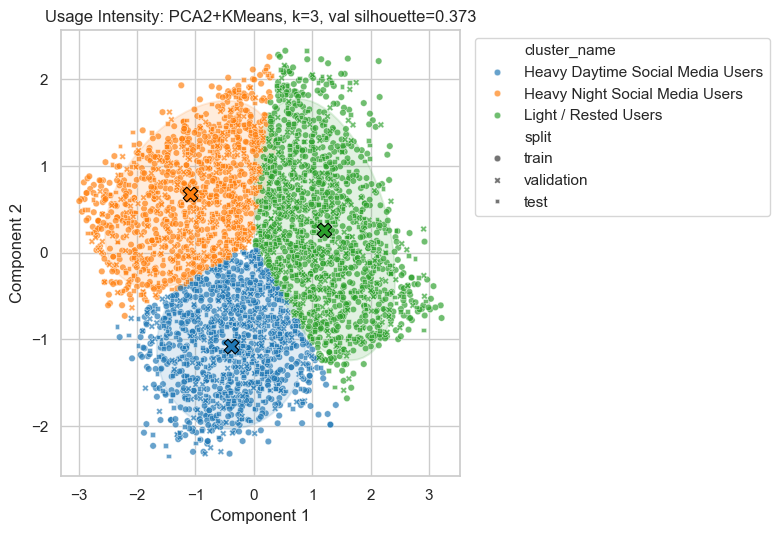

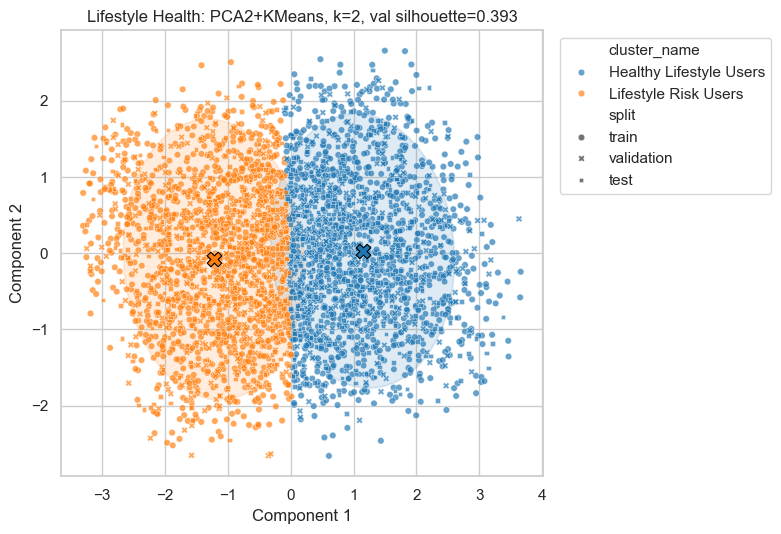

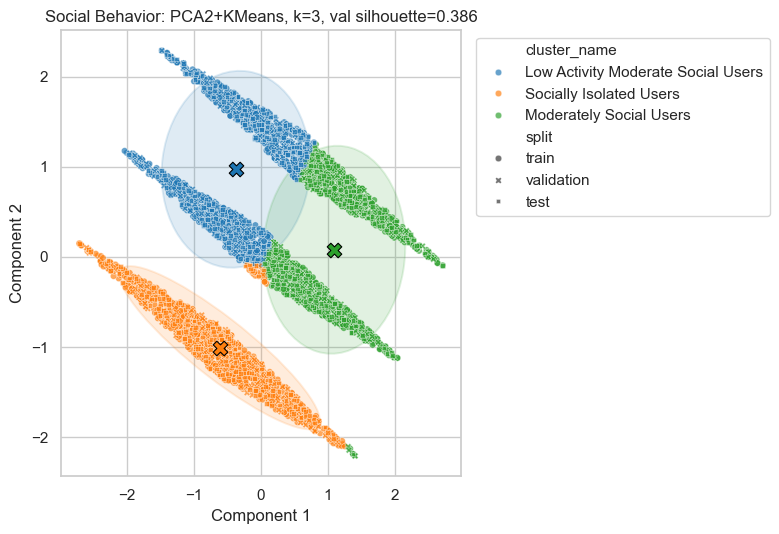

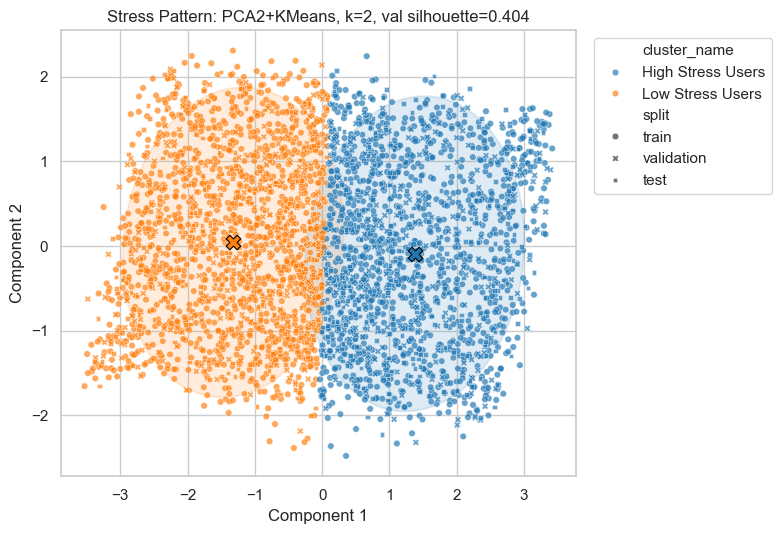

In [7]:
from matplotlib.patches import Ellipse


def add_cluster_ellipse(ax, points, color, n_std=1.8, alpha=0.14):
    if len(points) < 3:
        return
    cov = np.cov(points, rowvar=False)
    if not np.isfinite(cov).all():
        return
    vals, vecs = np.linalg.eigh(cov)
    vals = np.maximum(vals, 1e-8)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(vals)
    center = points.mean(axis=0)
    ellipse = Ellipse(
        xy=center,
        width=width,
        height=height,
        angle=angle,
        facecolor=color,
        edgecolor=color,
        linewidth=1.4,
        alpha=alpha,
        zorder=1,
    )
    ax.add_patch(ellipse)
    ax.scatter(
        center[0],
        center[1],
        marker='X',
        s=110,
        c=[color],
        edgecolors='black',
        linewidths=0.8,
        zorder=4,
    )


for view_name, artifact in artifacts.items():
    spec = multi_view_specs[view_name]
    best = best_by_view[view_name]
    X_plot_source = best['embeddings']['all']

    if X_plot_source.shape[1] == 2:
        plot_points = X_plot_source
        x_label, y_label = 'Component 1', 'Component 2'
    else:
        plot_points = PCA(n_components=2, random_state=SEED).fit_transform(X_plot_source)
        x_label, y_label = 'PCA 1', 'PCA 2'

    labels = artifact['kmeans'].predict(X_plot_source)
    plot_df = pd.DataFrame({
        'x': plot_points[:, 0],
        'y': plot_points[:, 1],
        'cluster_id': labels,
        'cluster_name': [artifact['cluster_name_map'][label] for label in labels],
        'split': all_df['split'].values,
    })

    cluster_names = plot_df['cluster_name'].drop_duplicates().tolist()
    colors = dict(zip(cluster_names, sns.color_palette('tab10', n_colors=len(cluster_names))))

    fig, ax = plt.subplots(figsize=(8, 5.5))
    for cluster_name in cluster_names:
        cluster_points = plot_df.loc[plot_df['cluster_name'] == cluster_name, ['x', 'y']].values
        add_cluster_ellipse(ax, cluster_points, colors[cluster_name])

    sns.scatterplot(
        data=plot_df,
        x='x',
        y='y',
        hue='cluster_name',
        style='split',
        palette=colors,
        s=22,
        alpha=0.68,
        ax=ax,
        zorder=3,
    )
    ax.set_title(f'{spec["display_name"]}: {artifact["method"]}, k={artifact["k"]}, val silhouette={best["val_silhouette"]:.3f}')
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f'{view_name}_best_clusters.png', dpi=160)
    plt.show()


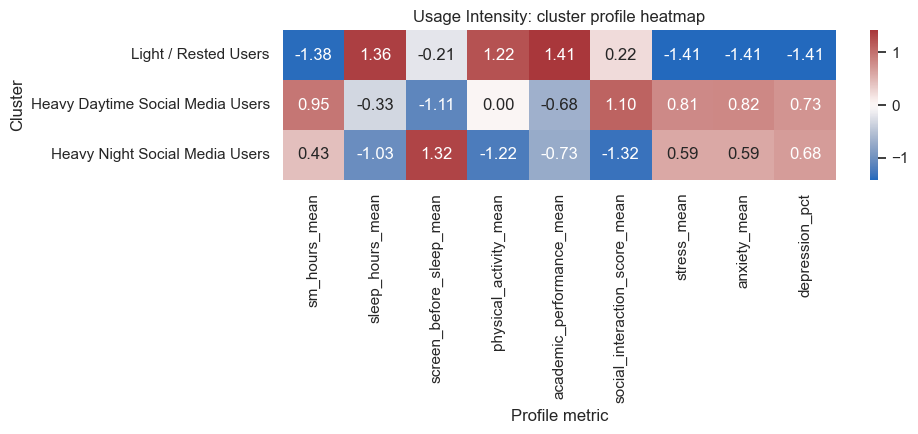

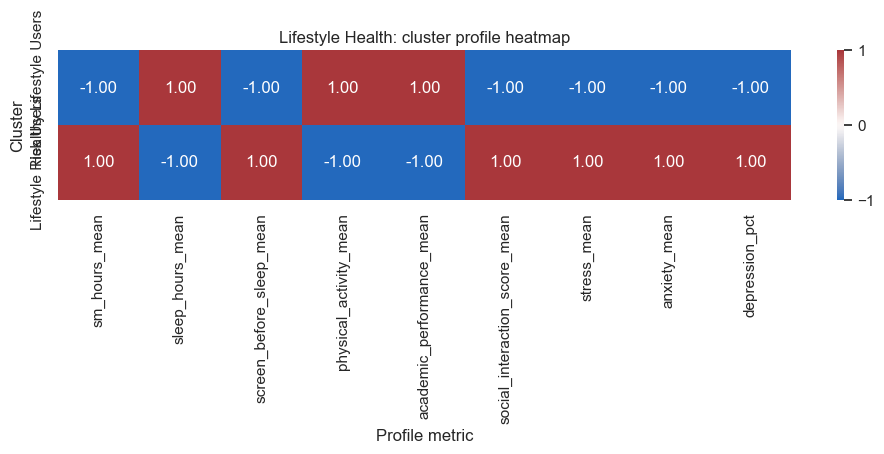

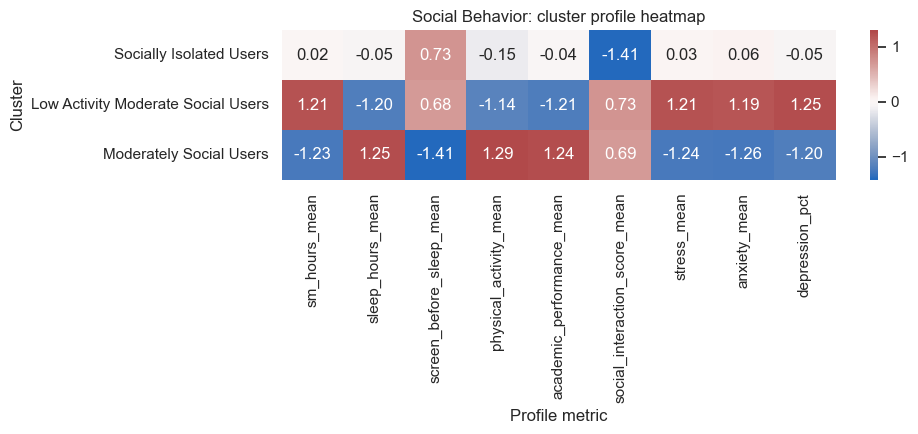

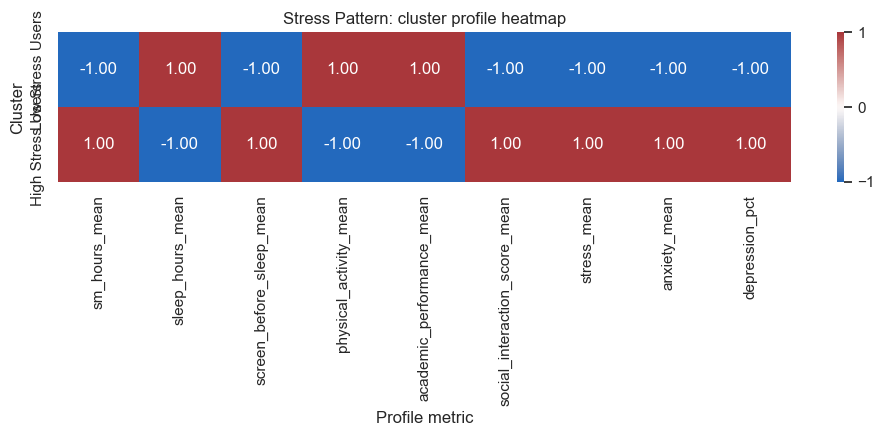

In [8]:
for view_name, spec in multi_view_specs.items():
    view_profiles = multi_view_profiles[multi_view_profiles['view'] == view_name].copy()
    heatmap_cols = [
        'sm_hours_mean',
        'sleep_hours_mean',
        'screen_before_sleep_mean',
        'physical_activity_mean',
        'academic_performance_mean',
        'social_interaction_score_mean',
        'stress_mean',
        'anxiety_mean',
        'depression_pct',
    ]
    profile_plot = view_profiles.set_index('cluster_name')[heatmap_cols]
    profile_plot_z = (profile_plot - profile_plot.mean()) / profile_plot.std(ddof=0)

    plt.figure(figsize=(10, 4.5))
    sns.heatmap(profile_plot_z, annot=True, fmt='.2f', cmap='vlag', center=0)
    plt.title(f'{spec["display_name"]}: cluster profile heatmap')
    plt.xlabel('Profile metric')
    plt.ylabel('Cluster')
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f'{view_name}_best_profile_heatmap.png', dpi=160)
    plt.show()


## 7. Persona tổng hợp và predict user mới


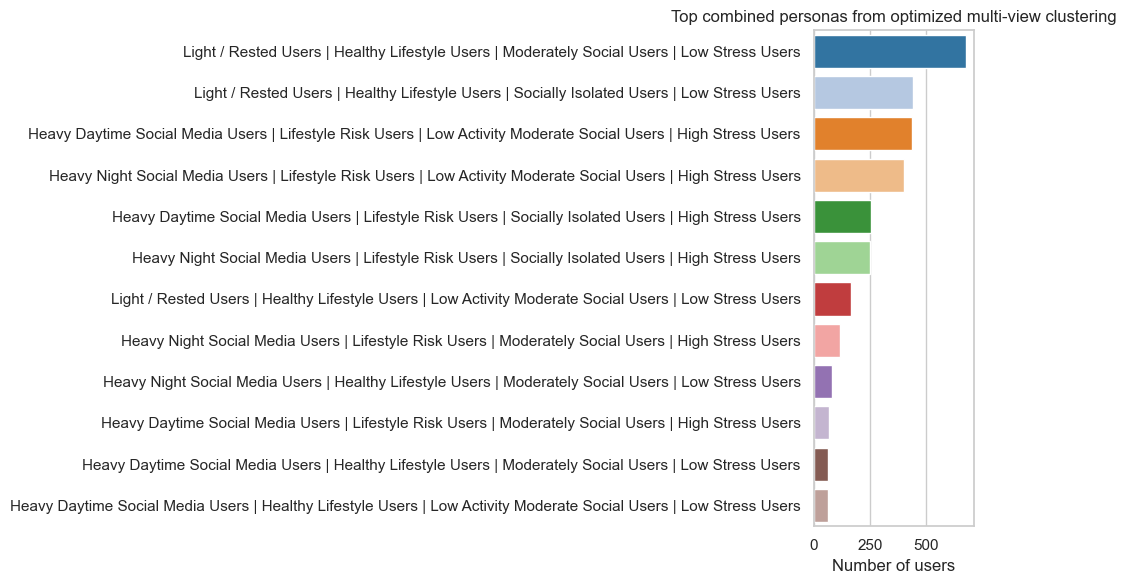

,combined_persona,n,pct
0,Light / Rested Users | Healthy Lifestyle Users...,679,0.183514
1,Light / Rested Users | Healthy Lifestyle Users...,442,0.119459
2,Heavy Daytime Social Media Users | Lifestyle R...,435,0.117568
3,Heavy Night Social Media Users | Lifestyle Ris...,400,0.108108
4,Heavy Daytime Social Media Users | Lifestyle R...,255,0.068919
5,Heavy Night Social Media Users | Lifestyle Ris...,249,0.067297
6,Light / Rested Users | Healthy Lifestyle Users...,166,0.044865
7,Heavy Night Social Media Users | Lifestyle Ris...,118,0.031892
8,Heavy Night Social Media Users | Healthy Lifes...,81,0.021892
9,Heavy Daytime Social Media Users | Lifestyle R...,68,0.018378


In [9]:
persona_summary = (
    multi_view_assignments['combined_persona']
    .value_counts()
    .rename_axis('combined_persona')
    .reset_index(name='n')
)
persona_summary['pct'] = persona_summary['n'] / persona_summary['n'].sum()
persona_summary.to_csv(CLUSTER_DIR / 'combined_persona_summary.csv', index=False)

plt.figure(figsize=(10, 6))
top_personas = persona_summary.head(12)
sns.barplot(data=top_personas, y='combined_persona', x='n', hue='combined_persona', palette='tab20', legend=False)
plt.title('Top combined personas from optimized multi-view clustering')
plt.xlabel('Number of users')
plt.ylabel('')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'combined_persona_top_counts.png', dpi=160)
plt.show()

persona_summary.head(12)


In [10]:
def predict_multi_view_persona(user_input, model_dir=MODEL_DIR):
    user_df = pd.DataFrame([user_input]).copy()
    user_df['social_interaction_score'] = encode_social_interaction(user_df['social_interaction_level'])

    predictions = {}
    persona_parts = []
    for view_name in multi_view_specs:
        row = multi_view_models[multi_view_models['view'] == view_name].iloc[0]
        artifact = joblib.load(ROOT / row['artifact_path'])
        X_user = artifact['scaler'].transform(user_df[artifact['features']])
        if artifact['reducer'] is not None:
            X_user = artifact['reducer'].transform(X_user)
        cluster_id = int(artifact['kmeans'].predict(X_user)[0])
        cluster_name = artifact['cluster_name_map'][cluster_id]
        predictions[view_name] = {
            'method': artifact['method'],
            'k': artifact['k'],
            'cluster_id': cluster_id,
            'cluster_name': cluster_name,
        }
        persona_parts.append(cluster_name)

    return {
        'views': predictions,
        'combined_persona': ' | '.join(persona_parts),
    }


example_user = {
    'daily_social_media_hours': 6.5,
    'sleep_hours': 5.2,
    'screen_time_before_sleep': 2.8,
    'physical_activity': 0.5,
    'social_interaction_level': 'medium',
    'academic_performance': 2.6,
    'stress_level': 8,
    'anxiety_level': 7,
}

predict_multi_view_persona(example_user)


{'views': {'usage_intensity': {'method': 'PCA2+KMeans',
   'k': 3,
   'cluster_id': 2,
   'cluster_name': 'Heavy Night Social Media Users'},
  'lifestyle_health': {'method': 'PCA2+KMeans',
   'k': 2,
   'cluster_id': 1,
   'cluster_name': 'Lifestyle Risk Users'},
  'social_behavior': {'method': 'PCA2+KMeans',
   'k': 3,
   'cluster_id': 1,
   'cluster_name': 'Low Activity Moderate Social Users'},
  'stress_pattern': {'method': 'PCA2+KMeans',
   'k': 2,
   'cluster_id': 1,
   'cluster_name': 'High Stress Users'}},
 'combined_persona': 'Heavy Night Social Media Users | Lifestyle Risk Users | Low Activity Moderate Social Users | High Stress Users'}

## 8. Output files


In [11]:
print('Candidate silhouette by view:')
display(clustering_model_metrics.groupby('view').head(5))

print('\nBest model per view:')
display(multi_view_models)

print('\nCluster profiles:')
display(multi_view_profiles)

print('\nSaved files:')
print(CLUSTER_DIR / 'multi_view_candidate_silhouette.csv')
print(CLUSTER_DIR / 'multi_view_clustering_metrics.csv')
print(CLUSTER_DIR / 'multi_view_cluster_profiles.csv')
print(CLUSTER_DIR / 'multi_view_cluster_assignments.csv')
print(CLUSTER_DIR / 'combined_persona_summary.csv')
print(MODEL_DIR / 'multi_view_clustering_models.csv')


Candidate silhouette by view:


,view,display_name,method,k,k_reason,train_silhouette,val_silhouette,test_silhouette
4,lifestyle_health,Lifestyle Health,PCA2+KMeans,2,Lifestyle separates most clearly into healthy ...,0.387932,0.392538,0.380738
5,lifestyle_health,Lifestyle Health,PCA3+KMeans,2,Lifestyle separates most clearly into healthy ...,0.296592,0.301230,0.289437
3,lifestyle_health,Lifestyle Health,KMeans,2,Lifestyle separates most clearly into healthy ...,0.249286,0.251297,0.242265
7,social_behavior,Social Behavior,PCA2+KMeans,3,"Social behavior naturally maps to isolated, mo...",0.399562,0.386124,0.397887
6,social_behavior,Social Behavior,KMeans,3,"Social behavior naturally maps to isolated, mo...",0.266915,0.250801,0.268568
8,social_behavior,Social Behavior,PCA3+KMeans,3,"Social behavior naturally maps to isolated, mo...",0.266915,0.250801,0.268568
10,stress_pattern,Stress Pattern,PCA2+KMeans,2,Stress/anxiety split is strongest and clearest...,0.407002,0.404053,0.407870
11,stress_pattern,Stress Pattern,PCA3+KMeans,2,Stress/anxiety split is strongest and clearest...,0.357316,0.357171,0.354468
9,stress_pattern,Stress Pattern,KMeans,2,Stress/anxiety split is strongest and clearest...,0.315462,0.310844,0.311535
1,usage_intensity,Usage Intensity,PCA2+KMeans,3,Usage intensity has three interpretable levels...,0.363755,0.372907,0.374827



Best model per view:


,view,display_name,method,k,train_silhouette,val_silhouette,test_silhouette,k_reason,selection_reason,artifact_path
0,usage_intensity,Usage Intensity,PCA2+KMeans,3,0.363755,0.372907,0.374827,Usage intensity has three interpretable levels...,fixed k from data interpretation; method selec...,models/clustering/usage_intensity_pca2pluskmea...
1,lifestyle_health,Lifestyle Health,PCA2+KMeans,2,0.387932,0.392538,0.380738,Lifestyle separates most clearly into healthy ...,fixed k from data interpretation; method selec...,models/clustering/lifestyle_health_pca2pluskme...
2,social_behavior,Social Behavior,PCA2+KMeans,3,0.399562,0.386124,0.397887,"Social behavior naturally maps to isolated, mo...",fixed k from data interpretation; method selec...,models/clustering/social_behavior_pca2pluskmea...
3,stress_pattern,Stress Pattern,PCA2+KMeans,2,0.407002,0.404053,0.407870,Stress/anxiety split is strongest and clearest...,fixed k from data interpretation; method selec...,models/clustering/stress_pattern_pca2pluskmean...



Cluster profiles:


,view,display_name,method,k,cluster_id,cluster_name,n,sm_hours_mean,sleep_hours_mean,screen_before_sleep_mean,physical_activity_mean,academic_performance_mean,social_interaction_score_mean,stress_mean,high_stress_pct,anxiety_mean,depression_pct
0,usage_intensity,Usage Intensity,PCA2+KMeans,3,0,Light / Rested Users,1417,2.704375,7.283204,1.620677,1.023006,3.281073,0.999294,3.500353,0.122089,3.443190,0.000706
1,usage_intensity,Usage Intensity,PCA2+KMeans,3,1,Heavy Daytime Social Media Users,1144,5.951049,5.931556,1.143444,0.997203,2.707142,1.004371,6.989510,0.620629,6.649476,0.271853
2,usage_intensity,Usage Intensity,PCA2+KMeans,3,2,Heavy Night Social Media Users,1139,5.223003,5.368218,2.432572,0.971378,2.694969,0.990342,6.646181,0.539069,6.312555,0.266023
3,lifestyle_health,Lifestyle Health,PCA2+KMeans,2,0,Healthy Lifestyle Users,1911,3.193668,7.012245,1.618106,1.069074,3.316211,0.986918,3.857666,0.142857,3.722135,0.002616
4,lifestyle_health,Lifestyle Health,PCA2+KMeans,2,1,Lifestyle Risk Users,1789,5.861375,5.489100,1.835159,0.924427,2.503376,1.010062,7.352711,0.684181,7.022359,0.340973
5,social_behavior,Social Behavior,PCA2+KMeans,3,0,Socially Isolated Users,1252,4.458466,6.273243,1.728115,0.970927,2.924577,0.027955,5.525559,0.397764,5.341853,0.155751
6,social_behavior,Social Behavior,PCA2+KMeans,3,1,Low Activity Moderate Social Users,1289,5.732118,5.935764,1.727773,0.703957,2.686028,1.508146,7.010861,0.619085,6.677269,0.301784
7,social_behavior,Social Behavior,PCA2+KMeans,3,2,Moderately Social Users,1159,3.122002,6.656687,1.712338,1.357895,3.185470,1.478861,3.943917,0.173425,3.779983,0.026747
8,stress_pattern,Stress Pattern,PCA2+KMeans,2,0,Low Stress Users,1884,3.101699,6.949363,1.687314,1.040234,3.227569,0.994161,3.435244,0.070594,3.287686,0.000531
9,stress_pattern,Stress Pattern,PCA2+KMeans,2,1,High Stress Users,1816,5.917126,5.576982,1.760132,0.956498,2.607423,1.002203,7.738987,0.751101,7.424009,0.338106



Saved files:
D:\DS-project\results\clustering\multi_view_candidate_silhouette.csv
D:\DS-project\results\clustering\multi_view_clustering_metrics.csv
D:\DS-project\results\clustering\multi_view_cluster_profiles.csv
D:\DS-project\results\clustering\multi_view_cluster_assignments.csv
D:\DS-project\results\clustering\combined_persona_summary.csv
D:\DS-project\models\clustering\multi_view_clustering_models.csv
